<a href="https://colab.research.google.com/github/wbb05/Connect4_MCTS/blob/main/Maze.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
from matplotlib.animation import ArtistAnimation
from IPython import display
import numpy as np

In [2]:
# Prim's algorithim

def findFrontier(cell, mazesize, maze):
  cellset = []
  if cell[0] + 2 < mazesize:
    cellset.append((cell[0] + 2, cell[1]))
  if cell[0] - 2 >= 0:
    cellset.append((cell[0] - 2, cell[1]))
  if cell[1] + 2 < mazesize:
    cellset.append((cell[0], cell[1] + 2))
  if cell[1] - 2 >= 0:
    cellset.append((cell[0], cell[1] - 2))


  ret = []
  for i,item in enumerate(cellset):
    if maze[item[0]][item[1]] == 0:

      ret.append(item)

  return ret

def findMaze(cell, mazesize, maze):
  cellset = []
  if cell[0] + 2 < mazesize:
    cellset.append((cell[0] + 2, cell[1]))
  if cell[0] - 2 >= 0:
    cellset.append((cell[0] - 2, cell[1]))
  if cell[1] + 2 < mazesize:
    cellset.append((cell[0], cell[1] + 2))
  if cell[1] - 2 >= 0:
    cellset.append((cell[0], cell[1] - 2))


  ret = []
  for i,item in enumerate(cellset):
    if maze[item[0]][item[1]] == 1:

      ret.append(item)

  return ret

def prim(maze, ax = None): # ax for showing
  frames = [] # For showing

  mazesize = len(maze)

  cells = [(0,0)]
  i = 0
  while cells:
    i += 1

    # Pick random from frontier
    newcellindex = np.random.choice([i for i in range(len(cells))])
    cell = cells.pop(newcellindex)
    maze[cell[0]][cell[1]] = 1

    # Find maze cell
    mazecells = findMaze(cell, mazesize, maze)

    # Connect cells
    if mazecells:

      newcellindex = np.random.choice([i for i in range(len(mazecells))])
      newcell = mazecells[newcellindex]
      maze[newcell[0]][newcell[1]] = 1
      maze[(newcell[0] + cell[0])//2][(newcell[1] + cell[1])//2] = 1

      if ax and i % mazesize == 0:
        frames.append([ax.imshow(maze, animated = True)]) # For showing

    # Expand frontier
    frontier = findFrontier(cell, mazesize, maze)

    for item in frontier:
      if item not in cells:
        cells.append(item)

    if i == 10000:
      print("Exceeded runtime")
      return frames
  return frames


In [3]:
# Depth-first search

def findFrontier(cell, mazesize, maze):
  cellset = []
  if cell[0] + 2 < mazesize:
    cellset.append((cell[0] + 2, cell[1]))
  if cell[0] - 2 >= 0:
    cellset.append((cell[0] - 2, cell[1]))
  if cell[1] + 2 < mazesize:
    cellset.append((cell[0], cell[1] + 2))
  if cell[1] - 2 >= 0:
    cellset.append((cell[0], cell[1] - 2))


  ret = []
  for i,item in enumerate(cellset):
    if maze[item[0]][item[1]] == 0:

      ret.append(item)

  return ret

def dfs(maze, ax = None):
  frames = [] # For showing

  mazesize = len(maze)
  stack = [(0,0)]

  current = (0,0)
  i = 0
  while stack:
    i += 1
    if i > 10000:
      print("Exceeded runtime")
      return frames
    neighbors = findFrontier(current, mazesize, maze)
    if neighbors:
      newcellindex = np.random.choice([i for i in range(len(neighbors))])
      newcell = neighbors[newcellindex]

      # Connect cells
      maze[current[0]][current[1]] = 1
      maze[newcell[0]][newcell[1]] = 1
      maze[(newcell[0] + current[0])//2][(newcell[1] + current[1])//2] = 1

      if ax and i % mazesize == 0:
        frames.append([ax.imshow(maze, animated = True)]) # For showing

      stack.append(newcell)
      current = newcell

    else:
      current = stack.pop(-1)

  return frames


In [4]:
def array_equal(a, b):
  for i in range(len(a)):
    if a[i] == b[i]:
      continue
    else:
      return False
  return True

def kruskal(maze, ax = None):
  frames = [] # For showing

  mazesize = len(maze)

  # Create walls, create cells
  walls = []
  cells = {}
  flop = True
  for i in range(mazesize):
    for j in range(mazesize):
      if flop:
        cells[(i,j)] = [(i,j)]
      else:
        walls.append((i,j))
      flop = not flop
    flop = not flop

  while walls:
    wallindex = np.random.choice([i for i in range(len(walls))])
    wall = walls.pop(wallindex)


    if wall[1] % 2 == 0: # Find left-right
      if  wall[1] - 1 < 0 or wall[1] + 1 >= mazesize:
        continue

      print(array_equal(cells[(wall[0], wall[1] - 1)], cells[(wall[0], wall[1] + 1)]))
      if not array_equal(cells[(wall[0], wall[1] - 1)], cells[(wall[0], wall[1] + 1)]):
        maze[wall[0]][wall[1] - 1] = 1
        maze[wall[0]][wall[1] + 1] = 1
        maze[wall[0]][wall[1]] = 1

        cells[(wall[0], wall[1] - 1)] += cells[(wall[0], wall[1] + 1)]
        cells[(wall[0], wall[1] + 1)] += cells[(wall[0], wall[1] - 1)]


    else:
      if  wall[0] - 1 < 0 or wall[0] + 1 >= mazesize:
        continue

      if not array_equal(cells[(wall[0] - 1, wall[1])], cells[(wall[0] + 1, wall[1])]):
        maze[wall[0] - 1][wall[1]] = 1
        maze[wall[0] + 1][wall[1]] = 1
        maze[wall[0]][wall[1]] = 1

        cells[(wall[0] - 1, wall[1])] += cells[(wall[0] + 1, wall[1])]
        cells[(wall[0] + 1, wall[1])] += cells[(wall[0] - 1, wall[1])]



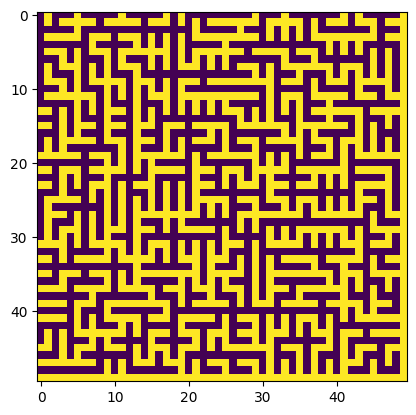

In [12]:
mazesize = 50
maze = np.array([[0 for _ in range(mazesize)] for _ in range(mazesize)])
prim(maze)
maze = 1 - maze
plt.imshow(maze)

In [8]:
mazesize = 100
maze = np.array([[0 for _ in range(mazesize)] for _ in range(mazesize)])

fig, ax = plt.subplots()

frames = dfs(maze, ax)

anim_created = ArtistAnimation(fig, frames, interval=200, blit = True)

video = anim_created.to_html5_video()
html = display.HTML(video)
display.display(html)

# good practice to close the plt object.
plt.close()

In [13]:
# A* Alg
#

class Node:
  def __init__(self, parent, position, cost):
    self.parent = parent
    self.position = position
    self.cost = cost

def add_stack(stack, a):
  for i,item in enumerate(stack):
    if a.cost < item.cost:
      stack.insert(i, a)
      return
  stack.append(a)
  return

# Manhatten distance
def heuristic(a, b):
  return abs(a[0] - b[0]) + abs(a[1] - b[1])

def extract(node):
  path = []
  while node.parent:
    path.append(node.position)
    node = node.parent
  path.reverse()
  return path

def a_star(maze, start, end):
  if maze[end[0]][end[1]] == 1:
    print("End is unreachable")
    return

  mazesize = len(maze)

  stack = [Node(None, start, heuristic(start, end))]
  prev = []
  i = 0
  while i < 100000:
    i += 1

    current = stack.pop(0)
    prev.append(current.position)

    currentdistance = current.cost - heuristic(current.position, end)

    for dx, dy in [(0,1), (1,0), (-1, 0), (0,-1)]:

      newnode = (current.position[0] + dx, current.position[1] + dy)

      if (0 <= newnode[0] < mazesize) and (0 <= newnode[1] < mazesize) and (maze[newnode[0]][newnode[1]] == 0): # 0?

        if newnode == end:
          return extract(Node(current, newnode,cost)), prev

        found = False
        for item in prev:
          if item == newnode:
            found = True

        if not found:
          cost =  currentdistance + heuristic(newnode, end)  #May need to be optimized
          add_stack(stack, Node(current, newnode, cost))

  print("Exceeded Runtime")
  return None



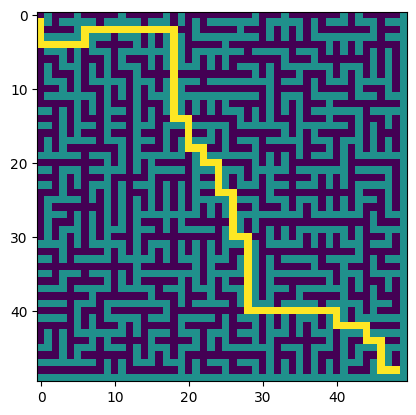

In [14]:
#print(maze)
a,prev = a_star(maze, (0,0), (mazesize - 2, mazesize-2))


for cell in a:
  maze[cell[0]][cell[1]] = 2

plt.imshow(maze)

In [15]:
print(len(prev))

688
